In [43]:
from datasets import load_dataset

In [44]:
#load cococaption dataset
dataset = load_dataset("phiyodr/coco2017")

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'image_id', 'ids', 'captions'],
        num_rows: 118287
    })
    validation: Dataset({
        features: ['license', 'file_name', 'coco_url', 'height', 'width', 'date_captured', 'flickr_url', 'image_id', 'ids', 'captions'],
        num_rows: 5000
    })
})


In [45]:
#sample
sample = dataset["train"][0]

print(sample)

{'license': 3, 'file_name': 'train2017/000000391895.jpg', 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg', 'height': 360, 'width': 640, 'date_captured': '2013-11-14 11:18:45', 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg', 'image_id': 391895, 'ids': [770337, 771687, 772707, 776154, 781998], 'captions': ['A man with a red helmet on a small moped on a dirt road. ', 'Man riding a motor bike on a dirt road on the countryside.', 'A man riding on the back of a motorcycle.', 'A dirt path with a young person on a motor bike rests to the foreground of a verdant area with a bridge and a background of cloud-wreathed mountains. ', 'A man in a red shirt and a red hat is on a motorcycle on a hill side.']}


In [46]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import random

#display random image caption pair
def show_sample(dataset):

    sample = random.choice(dataset["train"])

    response = requests.get(sample["coco_url"])
    image = Image.open(BytesIO(response.content)).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")

    print("Caption:\n")
    for c in sample["captions"]:
        print("-", c)


Caption:

- A man talking on a cell phone while holding a shepherds staff.
- Man in a yellow shirt standing in front of a group of people. 
- an image of woman with a beard in the desert
- a man with a big yellow scarf standing in the road
- An old man walking on the roadside with a staff.


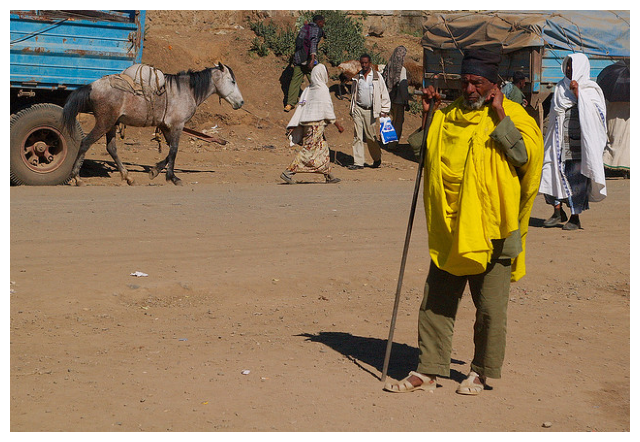

In [47]:
show_sample(dataset)

In [48]:
#convert to chat format

def convert_to_chat(sample):

    caption = random.choice(sample["captions"])

    return {
        "image_url": sample["coco_url"],
        "messages": [
            {
                "role": "user",
                "content": "<image>\nDescribe the image."
            },
            {
                "role": "assistant",
                "content": caption.strip()
            }
        ]
    }

In [49]:
#apply format
chat_dataset = dataset["train"].map(convert_to_chat)
chat_dataset[0]

{'license': 3,
 'file_name': 'train2017/000000391895.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'height': 360,
 'width': 640,
 'date_captured': '2013-11-14 11:18:45',
 'flickr_url': 'http://farm9.staticflickr.com/8186/8119368305_4e622c8349_z.jpg',
 'image_id': 391895,
 'ids': [770337, 771687, 772707, 776154, 781998],
 'captions': ['A man with a red helmet on a small moped on a dirt road. ',
  'Man riding a motor bike on a dirt road on the countryside.',
  'A man riding on the back of a motorcycle.',
  'A dirt path with a young person on a motor bike rests to the foreground of a verdant area with a bridge and a background of cloud-wreathed mountains. ',
  'A man in a red shirt and a red hat is on a motorcycle on a hill side.'],
 'image_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'messages': [{'content': '<image>\nDescribe the image.', 'role': 'user'},
  {'content': 'Man riding a motor bike on a dirt road on the countryside.',
 

In [50]:
def clean_sample(sample):
    return{
        "image_url": sample["image_url"],
        "messages": sample["messages"]
    }

In [51]:
#cleaned dataset
chat_dataset = chat_dataset.map(clean_sample, remove_columns=chat_dataset.column_names)

In [52]:
chat_dataset[0]

{'image_url': 'http://images.cocodataset.org/train2017/000000391895.jpg',
 'messages': [{'content': '<image>\nDescribe the image.', 'role': 'user'},
  {'content': 'Man riding a motor bike on a dirt road on the countryside.',
   'role': 'assistant'}]}

[{'content': '<image>\nDescribe the image.', 'role': 'user'}, {'content': 'Man riding a motor bike on a dirt road on the countryside.', 'role': 'assistant'}]


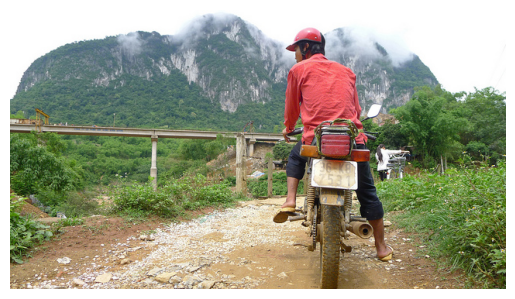

In [53]:
#visualize sample

sample = chat_dataset[0]
image = Image.open(BytesIO(requests.get(sample["image_url"]).content))

plt.imshow(image)
plt.axis("off")

print(sample["messages"])

In [54]:
import os

#directory for images
os.makedirs("images", exist_ok=True)

def download_image(sample):
    url = sample["image_url"]
    img_id = url.split("/")[-1]
    path = f"images/{img_id}"

    if not os.path.exists(path):
        img = requests.get(url).content
        with open(path, "wb") as f:
            f.write(img)

    return {"image_path": path}

In [55]:
subset_size = 5000
chat_dataset = chat_dataset.select(range(subset_size))

In [56]:
chat_dataset = chat_dataset.map(download_image)

In [57]:
#remove image_url column
chat_dataset = chat_dataset.remove_columns("image_url")
chat_dataset[0]

{'messages': [{'content': '<image>\nDescribe the image.', 'role': 'user'},
  {'content': 'Man riding a motor bike on a dirt road on the countryside.',
   'role': 'assistant'}],
 'image_path': 'images/000000391895.jpg'}

In [58]:
#visualse downloaded caption image pair randomly
def show_downloaded_sample(dataset):

    sample = random.choice(dataset)

    image = Image.open(sample["image_path"])

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")

    print("Caption:\n")
    for c in sample["messages"]:
        print("-", c)

Caption:

- {'content': '<image>\nDescribe the image.', 'role': 'user'}
- {'content': 'Adults and children gather near a dock on the beach.', 'role': 'assistant'}


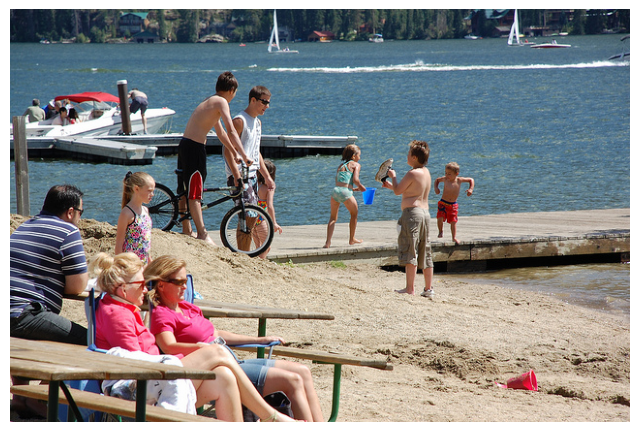

In [59]:
show_downloaded_sample(chat_dataset)